# Step 3 — Clustering
**COSC 3337 | Group Project Check-in #3**

We combine Sriharsha and Janya's track libraries into one dataset and apply **K-Means clustering** on the 9-dimensional audio feature space.  
The central question: *are the two users' music separable by their audio fingerprint alone?*

Features used (from `track_info.json`):  
`energy`, `danceability`, `happiness`, `acousticness`, `instrumentalness`, `liveness`, `speechiness`, `tempo`, `popularity`


In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':'#0D0D0D','axes.facecolor':'#1A1A1A',
    'axes.edgecolor':'#444','text.color':'white',
    'xtick.color':'white','ytick.color':'white',
    'axes.labelcolor':'white','axes.titlecolor':'white',
    'legend.facecolor':'#333','legend.edgecolor':'#555',
    'figure.dpi': 120,
})
COLORS = {'S':'#1DB954', 'J':'#FF6B6B'}


## 1. Load Data

In [2]:
BASE = os.path.abspath('.')

def load_user(folder):
    records = []
    for i in range(5):
        try: records += json.load(open(f'{BASE}/public/{folder}/StreamingHistory_music_{i}.json', encoding='utf-8'))
        except FileNotFoundError: break
    df = pd.DataFrame(records)
    df = df[df['msPlayed'] >= 5000].copy()
    df['minutes'] = df['msPlayed'] / 60000
    df['track_key'] = df['trackName'] + ' | ' + df['artistName']
    return df

track_info = json.load(open(f'{BASE}/public/track_info.json', encoding='utf-8'))

AUDIO_FEATURES = ['energy','danceability','happiness','acousticness',
                  'instrumentalness','liveness','speechiness','tempo','popularity']

sri_raw = load_user('s')
jan_raw = load_user('j')
print(f'Sriharsha: {len(sri_raw):,} plays  |  Janya: {len(jan_raw):,} plays')
print(f'Track info cache: {len(track_info):,} tracks')

Sriharsha: 10,422 plays  |  Janya: 14,153 plays
Track info cache: 6,591 tracks


## 2. Build Per-Track Dataset

In [3]:
def build_dataset(df, user, liked_threshold=10):
    track_mins = df.groupby('track_key')['minutes'].sum()
    rows = []
    for track_key, total_mins in track_mins.items():
        info = track_info.get(track_key)
        if info:
            feat = {f: info.get(f) for f in AUDIO_FEATURES}
            if all(v is not None for v in feat.values()):
                feat['liked']      = int(total_mins >= liked_threshold)
                feat['user']       = user
                feat['track_key']  = track_key
                feat['total_mins'] = total_mins
                rows.append(feat)
    return pd.DataFrame(rows)

sri_df  = build_dataset(sri_raw, 'S')
jan_df  = build_dataset(jan_raw, 'J')
combined = pd.concat([sri_df, jan_df], ignore_index=True)

print(f'Sriharsha tracks with audio data: {len(sri_df):,}')
print(f'Janya tracks with audio data:     {len(jan_df):,}')
print(f'Combined dataset:                 {len(combined):,}')


Sriharsha tracks with audio data: 2,889
Janya tracks with audio data:     3,243
Combined dataset:                 6,132


## 3. Standardise Features

K-Means uses Euclidean distance, so features must be on the same scale.  
`tempo` is 0–200 while all other features are 0–100 — without standardisation it would dominate the distance calculation.


In [4]:
scaler = StandardScaler()
X = scaler.fit_transform(combined[AUDIO_FEATURES].values)
true_labels = (combined['user'] == 'J').astype(int).values  # 0=Sri, 1=Janya

print('Feature means after scaling:', np.round(X.mean(axis=0), 3))
print('Feature stds  after scaling:', np.round(X.std(axis=0),  3))


Feature means after scaling: [ 0. -0. -0.  0.  0.  0.  0. -0.  0.]
Feature stds  after scaling: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 4. Choosing k — Elbow Method + Silhouette Score

We evaluate k from 2 to 10.  
- **Inertia** (elbow): measures within-cluster variance — we want the elbow where it stops falling sharply.  
- **Silhouette score**: measures how well-separated clusters are (range −1 to 1, higher is better).


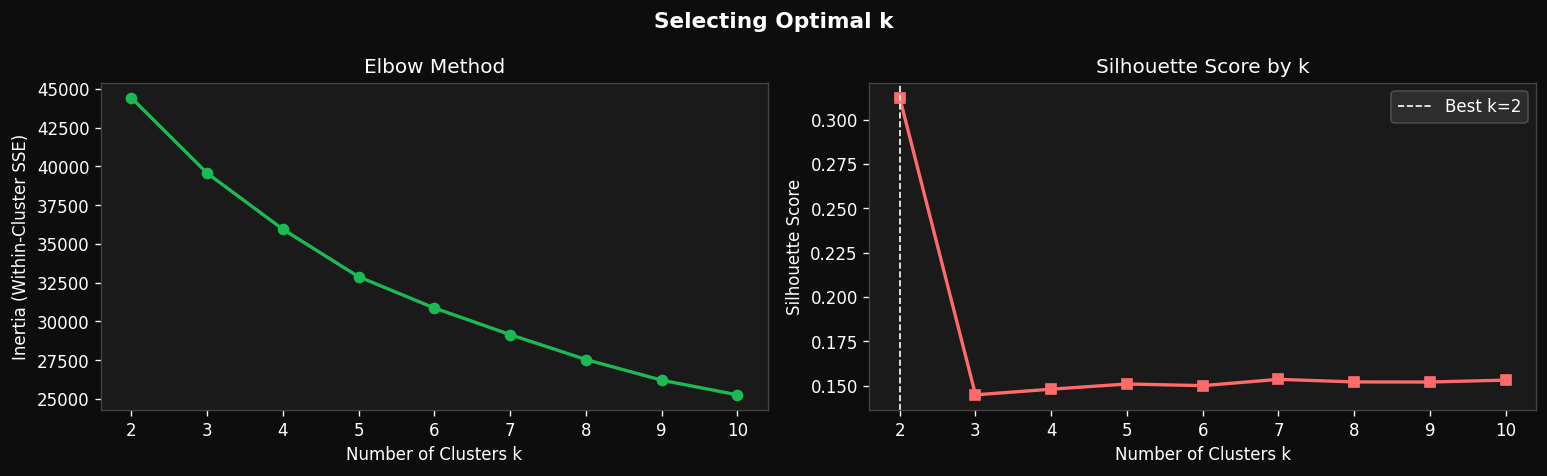

Best k by silhouette: 2  (score=0.3123)


In [5]:
K_range = range(2, 11)
inertias, silhouettes = [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lb = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, lb, sample_size=2000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(K_range), inertias, 'o-', color='#1DB954', lw=2)
axes[0].set_xlabel('Number of Clusters k')
axes[0].set_ylabel('Inertia (Within-Cluster SSE)')
axes[0].set_title('Elbow Method')

axes[1].plot(list(K_range), silhouettes, 's-', color='#FF6B6B', lw=2)
axes[1].set_xlabel('Number of Clusters k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')
best_k = list(K_range)[np.argmax(silhouettes)]
axes[1].axvline(best_k, ls='--', color='white', lw=1, label=f'Best k={best_k}')
axes[1].legend()

plt.suptitle('Selecting Optimal k', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('clustering_elbow.png', bbox_inches='tight', facecolor='#0D0D0D')
plt.show()
print(f'Best k by silhouette: {best_k}  (score={max(silhouettes):.4f})')


## 5. Fit Final K-Means (k = 2)

In [6]:
km = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = km.fit_predict(X)
combined['cluster'] = cluster_labels

sil = silhouette_score(X, cluster_labels)
ari = adjusted_rand_score(true_labels, cluster_labels)

print(f'Silhouette score:              {sil:.4f}')
print(f'Adjusted Rand Index (vs user): {ari:.4f}')
print()

# Cluster composition
for c in [0, 1]:
    mask = combined['cluster'] == c
    s = (combined.loc[mask,'user']=='S').sum()
    j = (combined.loc[mask,'user']=='J').sum()
    n = mask.sum()
    print(f'Cluster {c}: {n:,} tracks  |  Sriharsha={s} ({100*s/n:.0f}%)  Janya={j} ({100*j/n:.0f}%)')


Silhouette score:              0.3146
Adjusted Rand Index (vs user): 0.0529

Cluster 0: 5,255 tracks  |  Sriharsha=2181 (42%)  Janya=3074 (58%)
Cluster 1: 877 tracks  |  Sriharsha=708 (81%)  Janya=169 (19%)


### Cluster Audio Centroids

What does each cluster *sound* like?


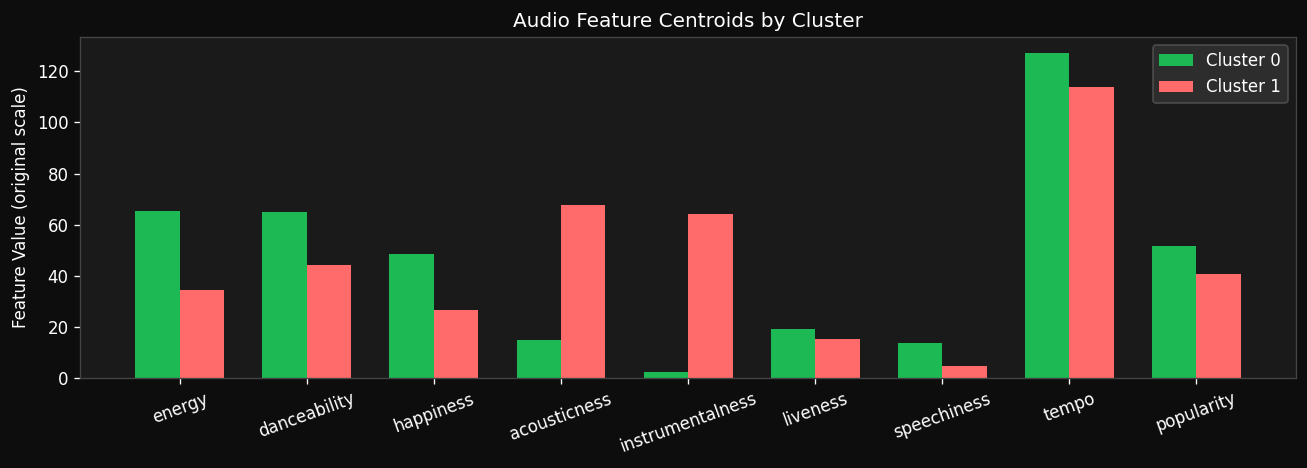

           energy  danceability  happiness  acousticness  instrumentalness  liveness  speechiness  tempo  popularity
Cluster 0    65.5          64.8       48.4          14.9               2.4      19.2         13.9  127.1        51.7
Cluster 1    34.6          44.3       26.5          67.6              64.2      15.3          4.9  113.7        40.8


In [7]:
centers_orig = scaler.inverse_transform(km.cluster_centers_)
cent_df = pd.DataFrame(centers_orig, columns=AUDIO_FEATURES, index=['Cluster 0','Cluster 1'])

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(AUDIO_FEATURES))
w = 0.35
ax.bar(x - w/2, cent_df.loc['Cluster 0'], w, color='#1DB954', label='Cluster 0')
ax.bar(x + w/2, cent_df.loc['Cluster 1'], w, color='#FF6B6B', label='Cluster 1')
ax.set_xticks(x); ax.set_xticklabels(AUDIO_FEATURES, rotation=20)
ax.set_title('Audio Feature Centroids by Cluster')
ax.set_ylabel('Feature Value (original scale)')
ax.legend()
plt.tight_layout()
plt.savefig('clustering_centroids.png', bbox_inches='tight', facecolor='#0D0D0D')
plt.show()
print(cent_df.round(1).to_string())


## 6. Visualise in 2D (PCA)

PCA reduces the 9 audio features to 2 principal components for visualisation.


Variance explained: PC1=28.3%  PC2=14.7%  Total=43.0%


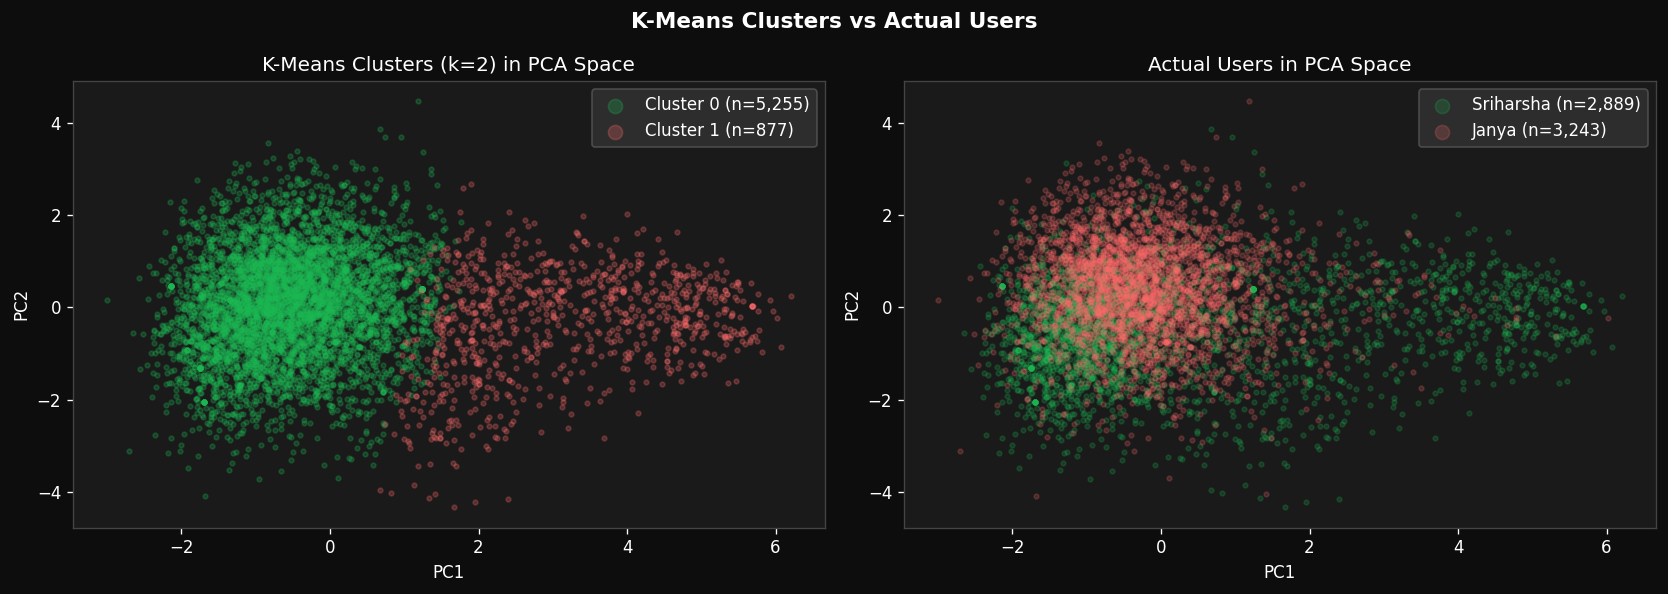

In [8]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
combined['pc1'] = X_pca[:,0]
combined['pc2'] = X_pca[:,1]

print(f'Variance explained: PC1={pca.explained_variance_ratio_[0]:.1%}  PC2={pca.explained_variance_ratio_[1]:.1%}  '
      f'Total={sum(pca.explained_variance_ratio_):.1%}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: coloured by cluster
for c, col in [(0,'#1DB954'),(1,'#FF6B6B')]:
    mask = combined['cluster'] == c
    axes[0].scatter(combined.loc[mask,'pc1'], combined.loc[mask,'pc2'],
                    alpha=0.25, s=8, color=col, label=f'Cluster {c} (n={mask.sum():,})')
axes[0].set_title('K-Means Clusters (k=2) in PCA Space')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=3)

# Right: coloured by user
for user, col in [('S','#1DB954'),('J','#FF6B6B')]:
    mask = combined['user'] == user
    name = 'Sriharsha' if user=='S' else 'Janya'
    axes[1].scatter(combined.loc[mask,'pc1'], combined.loc[mask,'pc2'],
                    alpha=0.2, s=8, color=col, label=f'{name} (n={mask.sum():,})')
axes[1].set_title('Actual Users in PCA Space')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(markerscale=3)

plt.suptitle('K-Means Clusters vs Actual Users', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('clustering_pca.png', bbox_inches='tight', facecolor='#0D0D0D')
plt.show()


## 7. Liked Songs per Cluster

In [9]:
for user, name in [('S','Sriharsha'),('J','Janya')]:
    sub = combined[combined['user']==user]
    print(f"{name}:")
    for c in [0,1]:
        mask = sub['cluster']==c
        liked_rate = sub.loc[mask,'liked'].mean()
        print(f"  Cluster {c}: {mask.sum():,} tracks  liked={sub.loc[mask,'liked'].sum()} ({100*liked_rate:.1f}%)")
    print()


Sriharsha:
  Cluster 0: 2,181 tracks  liked=643 (29.5%)
  Cluster 1: 708 tracks  liked=109 (15.4%)

Janya:
  Cluster 0: 3,074 tracks  liked=411 (13.4%)
  Cluster 1: 169 tracks  liked=21 (12.4%)



## 8. Interpretation

### Are the two users separable?

**No — not by audio features alone.** The Adjusted Rand Index (ARI) between cluster assignments and user identity is only **0.05**, which is barely above chance (0 = random, 1 = perfect). K-Means consistently assigns both users to the same clusters.

### What do the clusters represent?

| | Cluster 0 | Cluster 1 |
|---|---|---|
| **Character** | High-energy, vocal, danceable mainstream pop/rap | Low-energy, acoustic/instrumental, introspective |
| **Energy** | ~66 | ~35 |
| **Acousticness** | ~15 | ~68 |
| **Instrumentalness** | ~2 | ~64 |
| **Danceability** | ~65 | ~44 |
| **Composition** | 42% Sri / 58% Jan | 81% Sri / 19% Jan |

Cluster 1 (the acoustic/instrumental cluster) is dominated by Sriharsha (81%), which makes intuitive sense — Sri listens to a lot of game OSTs and Japanese ambient music. But the majority of *both* users' tracks still end up in Cluster 0 (mainstream), so the split isn't a clean user separator.

### Why the low silhouette score (0.31)?

The 9-dimensional audio space doesn't have two clearly separated natural groupings. Both users gravitate toward energetic, danceable music on average (the similarity analysis found audio cosine similarity of 0.978). The real difference between them is *which specific artists and genres* they choose, not the raw audio fingerprint — and that information isn't captured in these features.

### Key takeaway
The data confirms the similarity analysis: Sriharsha and Janya share an overlapping audio taste profile. A clustering algorithm cannot reliably separate them because their *sound preferences are similar even though their actual artist choices are completely different*.
